# 🌌 Linear regression!

## 🗂️ Project structure

1. Following the task description, you'll find a set of formal requirements that your solution must meet.
2. The primary measure of your success is the **test** accuracy of your machine learning model.
3. After completing each task, you must answer a series of questions, marked with ❓, to demonstrate your understanding of the techniques used.
4. You may create as many cells as needed, but the final results should be kept in a short and simple cell

## 🧪 A note on test data

In a departure from real-world scenarios, you will have access to the target variables of the test sets for each task. This has been arranged to facilitate the evaluation of your models. However, remember that in actual machine learning projects, test targets are not available, as predicting these is the ultimate goal of your supervised models.

## 📝 Submission guidelines

- For each problem, provide your code solution and model results inside **problem.ipynb** and **linear_models.py**.
- Answer the follow-up questions in markdown format within this notebook. A few sentences is enough, no requirements for length of answers.
- Ensure your explanations are clear, concise, and demonstrate a deep understanding of the techniques employed.
- Submit **problem.ipynb** and **linear_models.py** to Canvas. Deliever the notebook such that outputs are saved, ideally *restart* the kernel followed by *run all*.

Good luck!

---

## 🔋 Problem 1: Predicting power consumption

### ❗️ The problem

You must develop a predictive model to estimate **power consumption** based on **network activity**.
️
Use `LinearRegression` class from `linear_models.py` stored in this folder. Your task is to complete two functions: `fit` (find the optimal parameters of the regression) and `predict` (apply them to the test data).

### 📋 Formal requirements
1. **Implementation**: 
   - Use standard Python libraries (numpy, math, pandas, etc.)
   - Implement `LinearRegression` class from `linear_models.py` from scratch
   - Optimize weights and bias with gradient descent from scratch

2. **Discussion**:
   - Visualize the training loss curve. Is it stable?
   - Visualize the fitted curve and derive the resulting Energy consumption formula.
   - Analyze the prediction error distribution. What is an unbiased estimator?
   - What does it tell you when the gradient in SGD is close to zero?

In [14]:
# The `%autoreload` IPython magic command allows instant updates from `linear_models.py`.
%load_ext autoreload
%autoreload 2

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from project_1.linear_models import LinearRegression, LogisticRegression  # <--- You will implement this

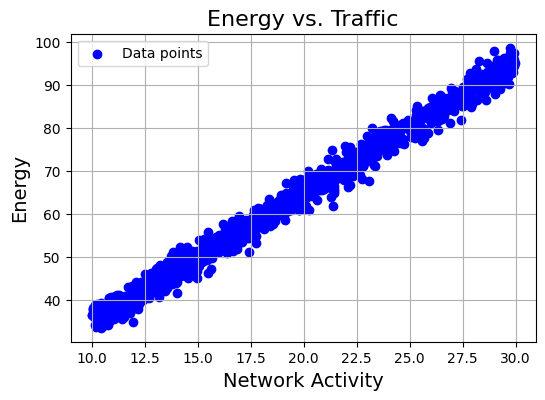

In [16]:
# Load data
df = pd.read_csv('regression.csv')

# Plot the data
plt.figure(figsize=(6, 4))
plt.scatter(df['Net_Activity'], df['Energy'], c='blue', label='Data points')
plt.grid(True)
plt.xlabel('Network Activity', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.title('Energy vs. Traffic', fontsize=16)
plt.legend()
plt.show()

In [17]:
df.shape

(1000, 2)

In [18]:
# ====================================
# YOUR CODE GOES HERE
train_epochs = 1000
lin_reg = LinearRegression(lr=.001, epochs=train_epochs)

df = pd.read_csv("regression.csv")
df.info


# ====================================

<bound method DataFrame.info of      Net_Activity     Energy
0       29.727959  98.734936
1       18.387504  61.864174
2       29.702529  92.981093
3       10.068594  37.812159
4       29.900919  96.367002
..            ...        ...
995     10.003400  36.311534
996     14.248588  51.047544
997     27.327307  87.074058
998     20.051893  61.064651
999     13.012001  44.269809

[1000 rows x 2 columns]>

In [19]:
#train test split
X_train = df[["Net_Activity"]][:700]
X_test = df[["Net_Activity"]][:300]
y_train = df[["Energy"]][:700]
y_test = df["Energy"][:300]

#Training
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)
y_pred.columns = ["Energy"]

c:\Users\seyon\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:86: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


[1471533.9768237332, 481726.1229681784, 158713.1486964812, 52872.707919299806, 17949.49622224163, 6289.155647306749, 2319.1495975367106, 924.9536698801544, 412.24299769814223, 211.53591837869962, 126.85200623888963, 88.23236575666908, 69.35292656755377, 59.608794684130686, 54.383889878528464, 51.51114906832081, 49.906204052104805, 49.00005767415208, 48.48438936282928, 48.1886942078055, 48.01750850788689, 47.916991263400426, 47.85664700368797, 47.819160700423744, 47.79468719912097, 47.77762413145162, 47.76478201259934, 47.754344560123656, 47.74527731993308, 47.736991073883836, 47.72915019090834, 47.72156348315429, 47.714122041215084, 47.70676382468291, 47.69945349193213, 47.69217091034587, 47.684904611182, 47.67764806111311, 47.670397538320195, 47.6631509225603, 47.65590700595435, 47.64866510035135, 47.64142481366818, 47.63418592248207, 47.62694829944712, 47.61971187194214, 47.61247659853188, 47.60524245553998, 47.5980094294036, 47.590777512328984, 47.58354669980322, 47.576316989181485,

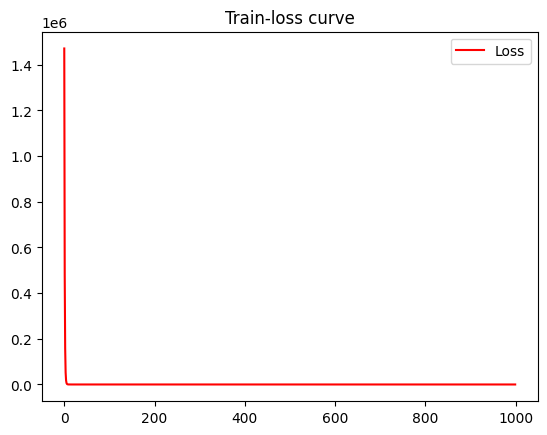

In [20]:
epoch_list = np.arange(0, train_epochs,1)

print(lin_reg.loss_history)
plt.plot(epoch_list, lin_reg.loss_history, c="red", label="Loss")
plt.legend()
plt.title("Train-loss curve")
plt.show()


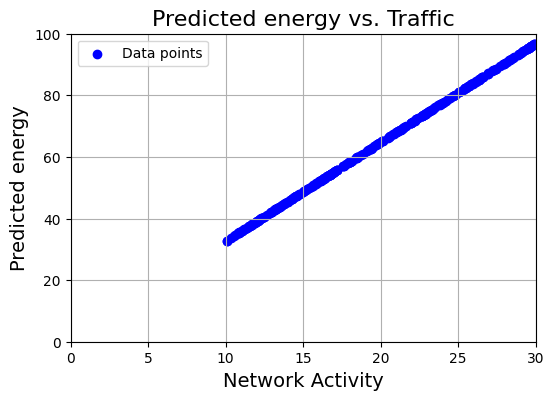

In [21]:
# Plot the data
plt.figure(figsize=(6, 4))
plt.scatter(X_test, y_pred["Energy"], c='blue', label='Data points')
plt.grid(True)
plt.xlabel('Network Activity', fontsize=14)
plt.ylabel('Predicted energy', fontsize=14)
plt.title('Predicted energy vs. Traffic', fontsize=16)
plt.xlim(0, 30)
plt.ylim(0, 100)
plt.legend()
plt.show()

In [22]:
plt.scatter(X_test, y_pred["err"], c='blue', label='Data points')
plt.xlabel('Network Activity', fontsize=14)
plt.title('Predicted error distrubution', fontsize=16)

KeyError: 'err'

In [ ]:
type(y_test), y_pred

y_pred["err"] = y_test - y_pred["Energy"]
y_pred

,Energy,err
0,96.020359,2.714577
1,59.584173,2.280001
2,95.938653,-2.957560
3,32.856025,4.956133
4,96.576070,-0.209067
...,...,...
295,85.130733,-3.550808
296,83.150932,-0.371485
297,77.001789,-1.768187
298,69.320441,-4.068448


### ❓ Is the training loss curve stable?
For training_epochs around 500
### ❓ Derive the resulting energy consumption formula
E(N) = 35 + (5)/(20)N
### ❓ Analyze prediction error distribution. What is an unbiased estimator?

### ❓ What does it tell you when the gradient in SGD is close to zero?
We have dropped at the minimum point

## 🔋 Problem 2: Logistic regression

### Your task
1. Implement logistic regression
2. Train your model on binary classification data
3. Engineer features to improve the model's performance

### Formal requirements
1. **Implementation**:
   - Same as before, use standard libraries
   - Implement gradient descent

2. **Performance**: Achieve at least **0.88** classification accuracy on the test set

3. **Discussion**:
   - Explain poor initial performance and your improvements
   - What is the model's inductive bias. Why is it important?
   - Plot the ROC curve, what does the area under the curve measure?

In [48]:
data = pd.read_csv('classification.csv')
train = data[data['split'] == 'train']
test = data[data['split'] == 'test']

train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x0      500 non-null    float64
 1   x1      500 non-null    float64
 2   y       500 non-null    float64
 3   split   500 non-null    object 
dtypes: float64(3), object(1)
memory usage: 19.5+ KB


In [40]:
train.head() 
X_train = train[["x0", "x1"]] / train[["x0", "x1"]].max()
y_train = train["y"]

X_test = test[["x0", "x1"]] / test[["x0", "x1"]].max()
y_test = test[["y"]]

y_train

0      0.0
1      1.0
2      0.0
3      1.0
4      0.0
      ... 
495    1.0
496    1.0
497    1.0
498    1.0
499    0.0
Name: y, Length: 500, dtype: float64

In [105]:
train_epochs = 300
log_reg = LogisticRegression(epochs=train_epochs, lr = 0.1)
log_reg.fit(X_train,y_train)
y_pred = log_reg.predict(X_test)

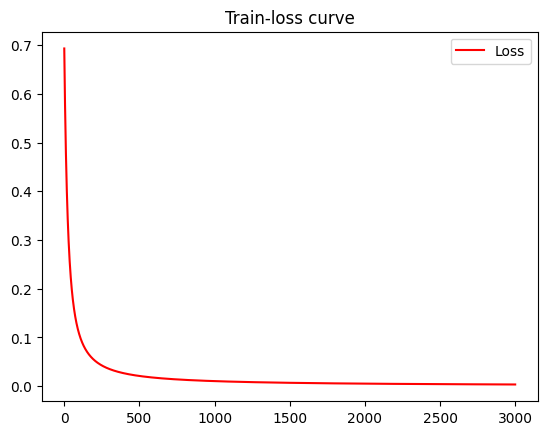

In [104]:
epoch_list = np.arange(0, train_epochs,1)

plt.plot(epoch_list, log_reg.loss_history, c="red", label="Loss")
plt.legend()
plt.title("Train-loss curve")
plt.show()



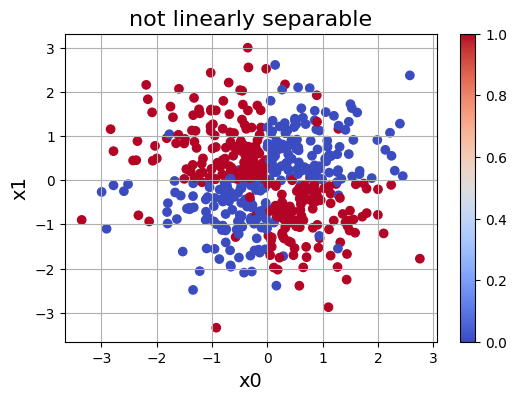

In [ ]:
# visualize x0 and x1 of train on scatterplot with colors corresponding to y
plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('not linearly separable', fontsize=16)
plt.colorbar()
plt.show()

In [ ]:
# ====================================
# YOUR CODE GOES HERE
# ====================================

### ❓ Explain poor initial performance and your improvements

### ❓ What is the model's inductive bias? Why is it important?

### ❓ What does the area under the ROC curve measure?